In [1]:
print("Kernel is working!")

Kernel is working!


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


In [3]:
data_path = "../data"

print("Dataset path:", data_path)

Dataset path: ../data


In [4]:
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Random seed:", SEED)

Image size: (128, 128)
Batch size: 32
Random seed: 42


In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

print("Training dataset loaded successfully!")

Found 2527 files belonging to 6 classes.
Using 1769 files for training.
Training dataset loaded successfully!


In [6]:
validation_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

print("Validation/Test dataset loaded successfully!")

Found 2527 files belonging to 6 classes.
Using 758 files for validation.
Validation/Test dataset loaded successfully!


In [7]:
total_validation_test_batches = tf.data.experimental.cardinality(
    validation_test_dataset
).numpy()

print("Total batches:", total_validation_test_batches)

Total batches: 24


In [8]:
test_batches = total_validation_test_batches // 2

test_dataset = validation_test_dataset.take(test_batches)

validation_dataset = validation_test_dataset.skip(test_batches)

print("Validation and test datasets created successfully!")

Validation and test datasets created successfully!


In [9]:
train_images = tf.data.experimental.cardinality(train_dataset).numpy() * BATCH_SIZE
validation_images = tf.data.experimental.cardinality(validation_dataset).numpy() * BATCH_SIZE
test_images = tf.data.experimental.cardinality(test_dataset).numpy() * BATCH_SIZE

print("Approximate dataset sizes:")
print("Training images:", train_images)
print("Validation images:", validation_images)
print("Test images:", test_images)

Approximate dataset sizes:
Training images: 1792
Validation images: 384
Test images: 384


In [10]:
class_names = train_dataset.class_names

print("Class names:")
for index, class_name in enumerate(class_names):
    print(index, "->", class_name)

Class names:
0 -> cardboard
1 -> glass
2 -> metal
3 -> paper
4 -> plastic
5 -> trash


In [11]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


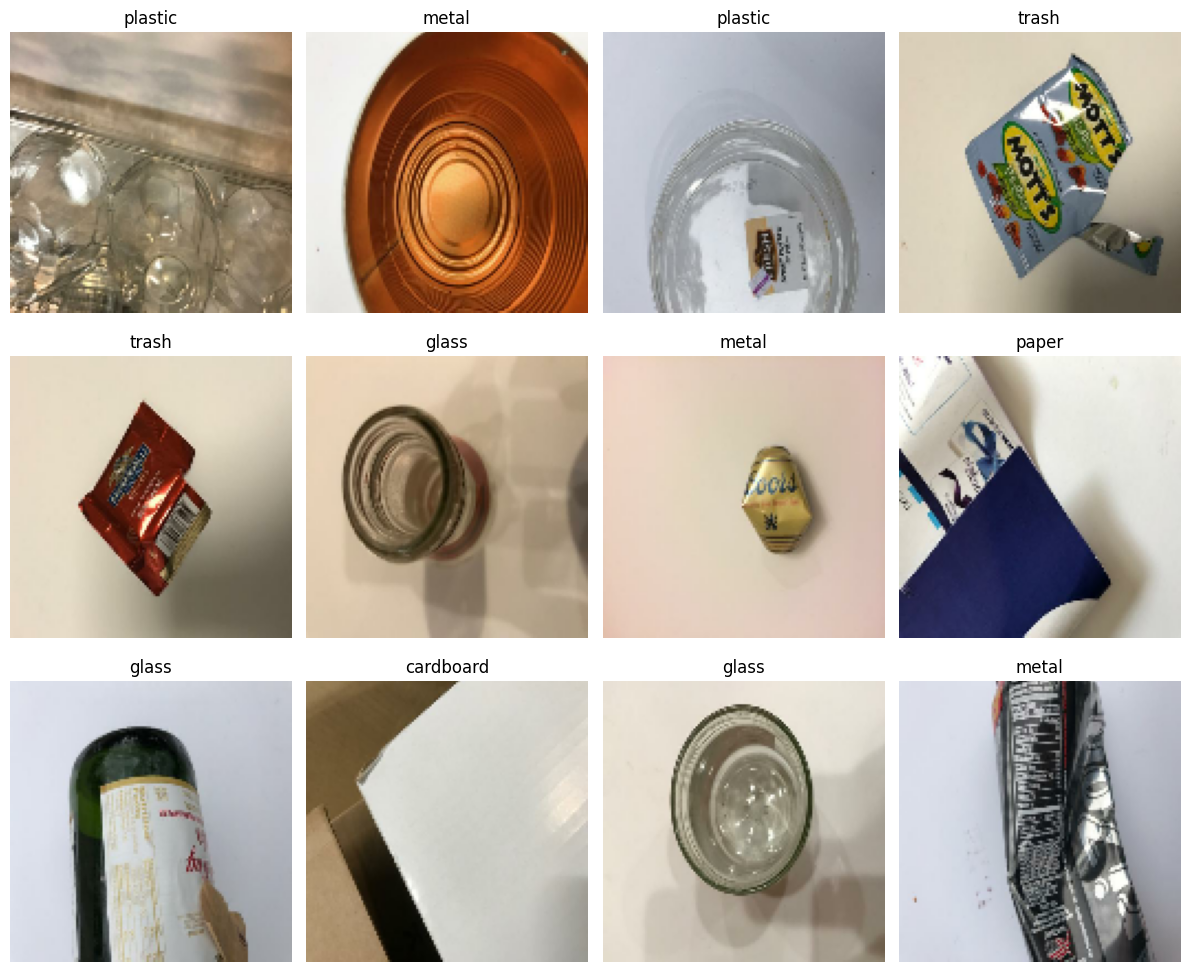

In [12]:
plt.figure(figsize=(12, 10))

for images, labels in train_dataset.take(1):
    
    for i in range(12):
        
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
normalization_layer = tf.keras.layers.Rescaling(
    1./255
)

print("Normalization layer created successfully!")

Normalization layer created successfully!


In [14]:
for images, labels in train_dataset.take(1):
    
    normalized_images = normalization_layer(images)
    
    print("Original minimum pixel value:",
          tf.reduce_min(images).numpy())
    
    print("Original maximum pixel value:",
          tf.reduce_max(images).numpy())
    
    print("Normalized minimum pixel value:",
          tf.reduce_min(normalized_images).numpy())
    
    print("Normalized maximum pixel value:",
          tf.reduce_max(normalized_images).numpy())

Original minimum pixel value: 0.0
Original maximum pixel value: 255.0
Normalized minimum pixel value: 0.0
Normalized maximum pixel value: 1.0


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset optimization completed!")

Dataset optimization completed!
